In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# CARREGANDO A BASE DE DADOS
df= pd.read_csv('Books_Data_Clean.csv')

# VISUALIZAR AS PRIMEIRAS LINHAS
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   object 
 3   Author               1070 non-null   object 
 4   language_code        1017 non-null   object 
 5   Author_Rating        1070 non-null   object 
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   object 
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   object 
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), object(6)
mem

In [4]:
df.isna().sum()

index                   0
Publishing Year         1
Book Name              23
Author                  0
language_code          53
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

Nestas informações acima podemos observar que as colunasque possuem valores nulos são:  
Publishing Year: 1 nulo  
Book Name: 23 nulos  
language_code: 53 nulos  


In [5]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


Analisando as informações acima, podemos observar que:
Publishing Year (Ano de publicação) conta o valor mímimo de -560, não existe ano negativo.
Book_average_rating (nota), esta na média de 4, sendo 75% acima de 4,17.
Book_ratings_count = (qtd de ratings recebidos)


## LIMPEZA E PRÉ PROCESSAMENTO

Observamos que tem datas com valores incorretos, entõa filtraremos as datas a partir de 1900.

In [6]:
# FILTRANDO DATAS A PARTIR DE 1900

df= df[df["Publishing Year"]>=1900]

In [7]:
df= df[~df["Book Name"].isna()]

Verificação de Duplicatas  
Utilizamos a função duplicated() para verificar linhas duplicadas, confirmando que não há registros repetidos.

In [8]:
df.duplicated().sum(

)

0

In [9]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

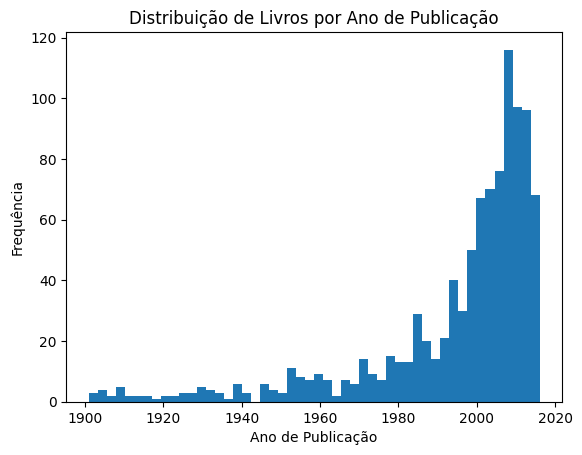

In [10]:
plt.hist(df["Publishing Year"], bins=50)
plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência')
plt.title('Distribuição de Livros por Ano de Publicação')
plt.show()

Distribuição de Gêneros  

Tratamos as categorias de gênero, combinando "general fiction" e "fiction" em uma única categoria para uma análise mais clara.



In [11]:
df["genre"].value_counts()

genre
genre fiction    759
nonfiction       160
fiction           54
children          15
Name: count, dtype: int64

In [12]:
# Tratando a categoria de gêneros genre fiction + fiction = fiction
df['genre'] = df['genre'].apply(lambda genre:'Ficção' if genre == "genre fiction" else genre)

In [13]:
df["genre"].value_counts()

genre
Ficção        759
nonfiction    160
fiction        54
children       15
Name: count, dtype: int64

<Axes: xlabel='genre'>

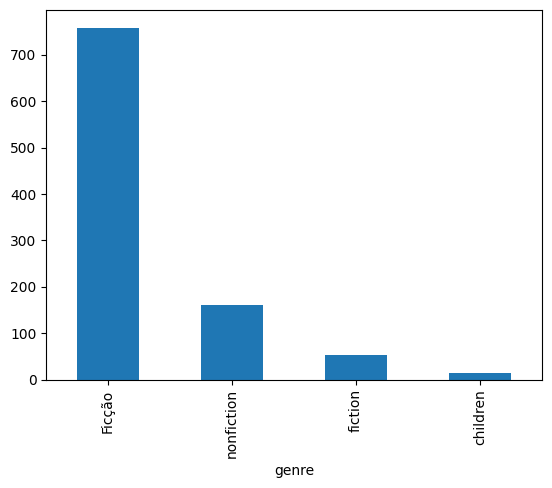

In [14]:
df["genre"].value_counts().plot(kind="bar")

Agrupando média de nota Autor

In [15]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

Text(0.5, 0, 'Gênero')

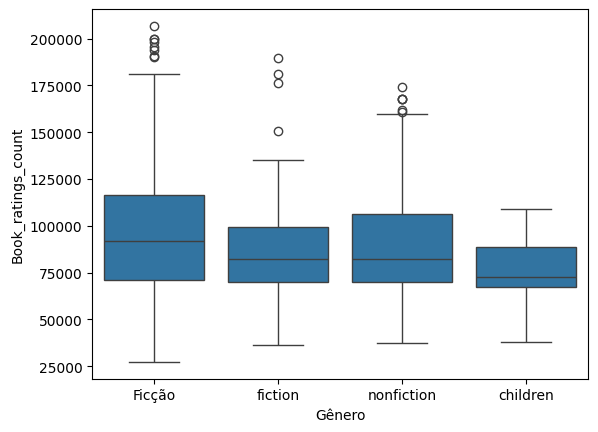

In [16]:
# Quantidade de avaliações por genero

sns.boxplot(x="genre", y="Book_ratings_count", data=df)
plt.xlabel("Gênero")

### 💡 Insights Principais do Gráfico

* **Ficção é o campeão de engajamento:** Os livros de **Ficção** (caixa azul) são os que costumam receber o maior volume de avaliações, superando Não-Ficção (laranja) e Infantis (verde).
* **Concentração vs. Dispersão:** Na caixa de Ficção, a linha da mediana está mais próxima do fundo. Isso mostra que os livros com menos avaliações estão muito **concentrados** (com números muito parecidos). Já na parte de cima da caixa, os dados ficam bem mais **dispersos** (espalhados), mostrando que a diferença de sucesso entre os livros mais famosos é bem maior.
* **Fenômenos de sucesso (Outliers):** Os pontinhos pretos no topo das caixas de Ficção e Não-Ficção representam os "super sucessos". São aqueles livros raros que bombaram tanto que ultrapassaram o limite normal do gráfico.
* **Gênero Infantil mais estável:** Os livros infantis (caixa verde) possuem o menor volume de avaliações, são mais parecidos entre si e não apresentam nenhum caso de super sucesso isolado (sem pontinhos pretos).


Text(0.5, 0, 'Gênero')

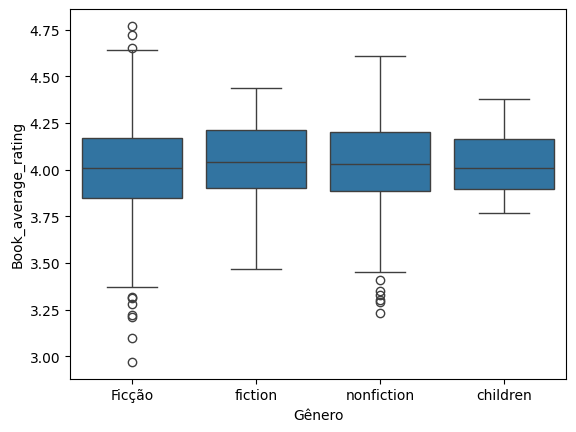

In [17]:
# Notas de avaliações por gênero

sns.boxplot(x="genre", y="Book_average_rating", data=df)
plt.xlabel("Gênero")

### 💡 Insights Principais do Gráfico (Notas Médias por Gênero)

* **Notas muito parecidas no meio:** A linha do meio (mediana) de todas as três caixas está quase na mesma altura, por volta da nota **4.0**. Isso significa que o livro "comum" de qualquer um dos três gêneros costuma receber notas muito parecidas dos leitores.
* **Equilíbrio perfeito (Simetria):** Diferente do gráfico anterior, as linhas pretas estão quase exatamente no centro geométrico das caixas. Isso mostra que as notas estão distribuídas de forma bem equilibrada: a mesma distância que existe para os 25% de livros acima da média é a que existe para os 25% abaixo dela.
* **Não-Ficção com público exigente:** A caixa de **Não-Ficção** (laranja) tem a maior parte do seu "miolo" ligeiramente acima das outras. Porém, ela tem pontinhos pretos **apenas na parte de baixo** (perto de 3.25). Isso significa que, embora a maioria goste muito, existem alguns livros de não-ficção que os leitores acharam bem ruins e deram notas muito baixas.
* **Ficção tem opiniões mais extremas:** A caixa de **Ficção** (azul) tem as "antenas" mais compridas e pontinhos pretos nos dois extremos. Isso significa que a ficção gera reações fortes: tem livros com notas altíssimas (quase 4.75) e também livros com notas super baixas (perto de 3.0).
* **Gênero Infantil é o mais consensual:** A caixa de **Livros Infantis** (verde) é a menor de todas, com as antenas mais curtas e nenhum pontinho preto. Isso nos diz que as notas desse gênero são muito parecidas e concentradas, sem grandes surpresas para cima ou para baixo.


### 📊 Resumo Comparativo: Volume de Avaliações vs. Notas Médias

Quando olhamos para os dois gráficos juntos, conseguimos entender não apenas o que as pessoas leem, mas como elas reagem a cada gênero de livro:

* **🔵 Ficção (O Gigante das Opiniões):**
  * **Volume:** É o gênero mais popular e disparado o que recebe mais avaliações (Gráfico 1).
  * **Notas:** Apesar de ser o mais avaliado, é o que causa as reações mais extremas (Gráfico 2). Ele tem livros amados com notas altíssimas (perto de 4.75) e livros odiados com notas muito baixas (perto de 3.0). Isso mostra que um público maior gera mais variedade de opiniões.

* **🟠 Não-Ficção (Leitores Engajados, mas Críticos):**
  * **Volume:** Fica em segundo lugar em quantidade de avaliações, mostrando que tem um público bem ativo.
  * **Notas:** O "miolo" das notas é um pouquinho mais alto que os outros gêneros, indicando que quem lê não-ficção costuma gostar bastante do que escolhe. Porém, o gráfico de notas mostra pontos muito baixos isolados (outliers no fundo), revelando que quando um livro de não-ficção é ruim, os leitores não perdoam e dão notas bem baixas.

* **🟢 Infantis / Children (O Reino da Estabilidade):**
  * **Volume:** É o gênero menos avaliado nos gráficos, o que é normal, já que crianças pequenas não costumam entrar na internet para avaliar livros.
  * **Notas:** É disparado o gênero mais equilibrado e sem surpresas. As notas são todas muito parecidas e não existem "livros odiados" ou "super favoritos" isolados (sem pontinhos pretos). É um público muito constante e previsível.

---

### 💡 Conclusão Geral da Análise
A **Ficção** move as grandes massas e gera debates intensos (muito volume e muita variação de notas). A **Não-Ficção** agrada muito seu público comum, mas pune severamente os livros ruins. Já os livros **Infantis** correm por fora, com menos barulho (menos avaliações), mas com uma aceitação super estável e positiva.


Text(0, 0.5, 'Units sold')

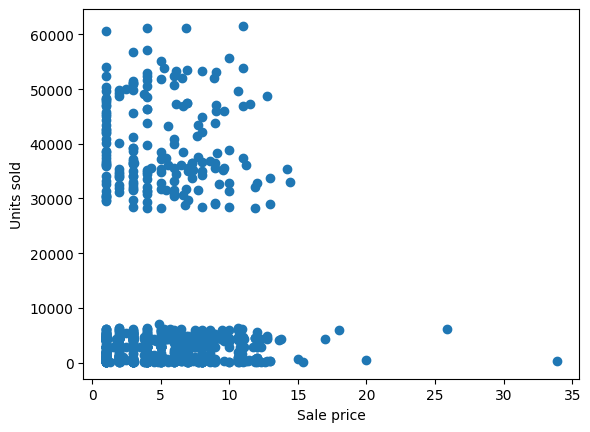

In [18]:
plt.scatter(df["sale price"], df["units sold"])
plt.xlabel("Sale price")
plt.ylabel("Units sold")

### 💡 Insights Principais do Gráfico (Preço vs. Vendas)

* **Os dois mundos de vendas (O grande espaço vazio):** O gráfico mostra uma divisão muito clara e curiosa. Existe um espaço gigante e vazio no meio do gráfico (entre 10 mil e 30 mil unidades vendidas). Isso significa que os livros ou vendem **muito pouco** (ficam na parte de baixo) ou vendem **demais** (ficam na parte de cima). Quase nenhum livro fica no meio termo.
* **Preço baixo não garante vendas altas:** Olhando para o lado esquerdo (preços entre 1 e 5), temos uma linha vertical cheia de bolinhas tanto no topo quanto no fundo. Isso mostra que colocar o livro bem baratinho faz alguns venderem muito (60 mil unidades), mas faz a grande maioria vender quase nada (perto de zero).
* **O limite dos livros caros:** Repare que as bolinhas da parte de cima (os livros que vendem muito) param de aparecer quando o preço passa de 15. Isso nos diz que **nenhum livro caro** (acima de 15) consegue alcançar o grupo dos super vendidos. Todos os livros mais caros ficam presos lá embaixo, vendendo menos de 10 mil unidades.


In [19]:
df["language_code"].value_counts()

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
spa        2
ara        2
nl         1
Name: count, dtype: int64

In [20]:
language_counts= df["language_code"].value_counts()

([<matplotlib.patches.Wedge at 0x2378692f170>,
 [Text(-0.6796686059953209, 0.8648991767971441, 'eng'),
  Text(0.5425622699726188, -0.9568835787085904, 'en-US'),
  Text(1.0772677713651677, -0.22247280458052568, 'en-GB'),
  Text(1.0961707584417664, -0.09170424383420113, 'en-CA'),
  Text(1.09879866753169, -0.05139541059844229, 'fre'),
  Text(1.099607678020548, -0.029376086163054815, 'spa'),
  Text(1.099901913934085, -0.014689442608105147, 'ara'),
  Text(1.0999938690861812, -0.0036725975566969534, 'nl')])

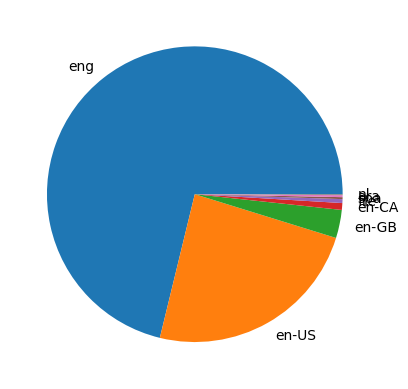

In [21]:
# Grafico de pizza
plt.pie(language_counts, labels=language_counts.index)

In [ ]:
# Agrupando receita por Publicadora

df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending=False)

Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

Publicadora que mais ganhou dinheiro foi Penguin Group

In [23]:
df["Author_Rating"].value_counts()

Author_Rating
Intermediate    576
Excellent       336
Famous           48
Novice           28
Name: count, dtype: int64

In [ ]:
# Quantidade de rating que cada autor recebeu de cada rating

df.groupby("Author_Rating")["Book_ratings_count"].sum()

Author_Rating
Excellent       28158413
Famous           4718172
Intermediate    58406557
Novice           2444917
Name: Book_ratings_count, dtype: int64

Famosos são menos, então menos livros

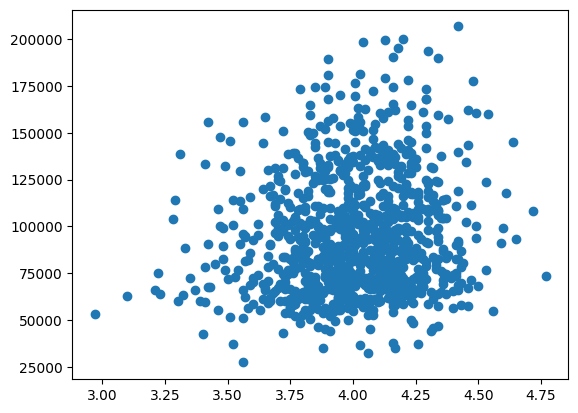

In [ ]:
#Existe relação entre a quantidade de rating vs o rating que são dados aos livros?

plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])

Aparentemente as pessoas que são mais rating, são as que estão mais satisfeitas com os produtos, ou menos satisfeitas. No meio do caminho não dão. Por isso é uma tendencia fraca.

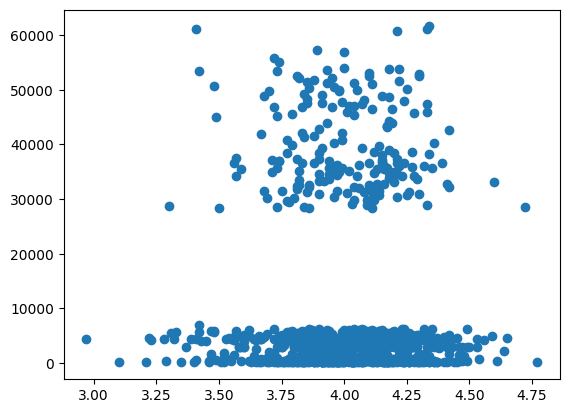

In [ ]:
# Relação entre rating e qtd vendidas
plt.scatter(df["Book_average_rating"],df["units sold"])

Rating com maior nota, tendem a vender mais? Não tem uma relação clara.

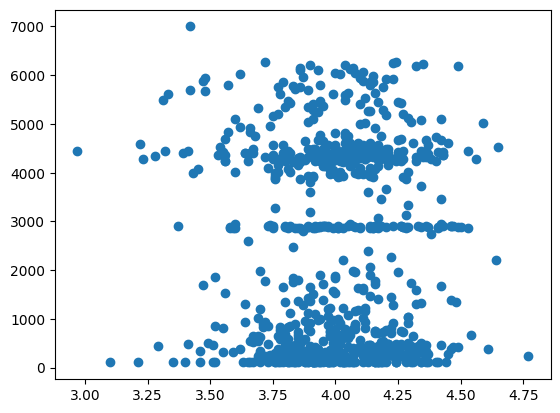

In [27]:
booleano= df["units sold"]< 10000

plt.scatter(df[booleano] ["Book_average_rating"], df[booleano]["units sold"])

In [ ]:
#Autores que mais venderam
df.groupby("Author")["gross sales"].sum().sort_values(ascending=False)

Author
Harper Lee              47795.00
Stephen King            43322.65
David Sedaris           42323.41
Charlaine Harris        39453.08
Laini Taylor            38278.41
                          ...   
Frank Warren              107.91
Ayaan Hirsi Ali           107.91
Walter M. Miller Jr.      106.92
Michael Shaara            105.93
Blake Crouch              105.93
Name: gross sales, Length: 669, dtype: float64

In [ ]:
#Correlação

df[["Book_average_rating", #Rating
    "Book_ratings_count", #Qtd de ratings
    "gross sales", #vendas brutas
    "sale price"]].corr() #preços das vendas

,Book_average_rating,Book_ratings_count,gross sales,sale price
Book_average_rating,1.000000,0.120600,-0.042815,-0.015232
Book_ratings_count,0.120600,1.000000,0.489752,-0.067698
gross sales,-0.042815,0.489752,1.000000,0.269951
sale price,-0.015232,-0.067698,0.269951,1.000000


1. A maior ligação:  
   Quantidade de Avaliações e Vendas Brutas  
   Onde olhar: Cruzamento de Book_ratings_count com gross sales.  
   
   O número: 0.489752  
   
   O que significa: Existe uma ligação moderada e positiva aqui. Isso indica que livros com mais avaliações costumam ter um valor total de vendas maior. Faz sentido: livros mais populares e comentados tendem a vender mais.

<Axes: xlabel='Author_Rating', ylabel='units sold'>

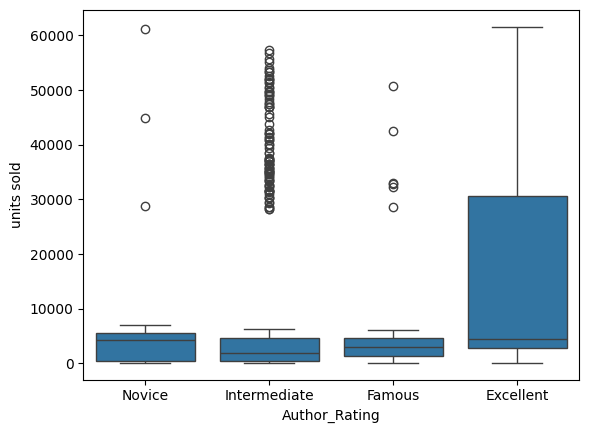

In [ ]:
#Tipo de avaliação vs qtd vendida

sns.boxplot(x="Author_Rating", y="units sold", data=df)


<Axes: xlabel='Publishing Year'>

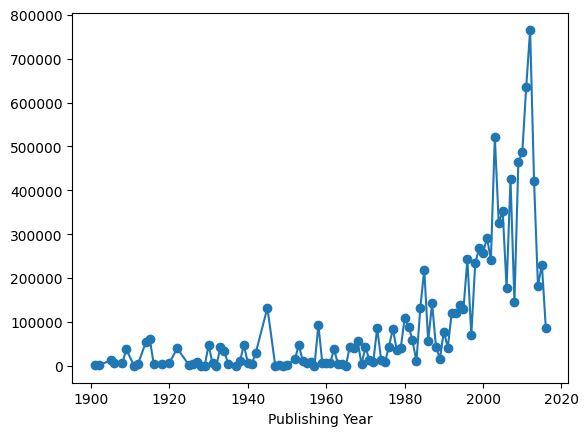

In [33]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line", marker="o")


In [ ]:
# diferença estatistica entre famosos e intermediarios
# Dois grupos (2 amostras), há diferença significativa?

import scipy.stats as stats

# Separando os grupos
grupo_A = df[df['Author_Rating'] == 'Famous']['units sold']
grupo_B = df[df['Author_Rating'] == 'Intermediate']['units sold']

# Realizando teste t de Student para amostras independentes
t_stats,p_val=stats.ttest_ind(grupo_A, grupo_B, equal_var=False)


#Exibir resultados

print(f"Estatística t: {t_stats:.4f}")
print(f"Valor p: {p_val:.4f}")

Estatística t: -0.6595
Valor p: 0.5121


Não existe diferença significativa. O rating não explica a quantidade que vai vender.